<img src='http://www-scf.usc.edu/~ghasemig/images/sharif.png' alt="SUT logo" width=500 height=300 align=center class="saturate" >

<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Intelligent Analysis of Biomedical Images <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2025<br>
<font color=3C99D size=5>
    Practical Assignment 2 - From Sinograms to CT Images <br>
<font color=696880 size=4>
Alireza Malekhosseini


**NAME:** Mobina Poulaei

**STUDENT NUMBER:** 403206962


# From Sinograms to CT Images + A Tiny DL Denoiser (100 + 5)
In this notebook You will implement:
1) Synthetic dataset of 1,000 randomized 128×128 phantoms (Shepp–Logan + ellipses)  
2) From-scratch Radon (forward) and FBP (filters: ramp, shepp-logan, hann)  
3) Low-dose Poisson noise & limited-angle experiments  
4) Metrics: PSNR, SSIM  
5) Tiny U-Net-lite denoiser (supervised L1/L2) trained on (FBP-noisy → Ground-truth)



In [ ]:
!pip install scikit-image torch torchvision matplotlib tqdm

In [ ]:
import math, random, os, time
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt

from skimage.data import shepp_logan_phantom
from skimage.transform import radon as sk_radon, iradon as sk_iradon, rotate
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import skimage.transform as skt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 0) Reproducibility & Config (0 pts)

In [ ]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
set_seed(42)

# You can change
@dataclass
class CFG:
    img_size: int = 128
    n_train: int = 800
    n_val: int = 100
    n_test: int = 100
    angles_180: int = 180
    limited_deg: int = 120
    I0: float = 1e4
    eps: float = 1e-8
CFG = CFG(); CFG

CFG(img_size=128, n_train=800, n_val=100, n_test=100, angles_180=180, limited_deg=120, I0=10000.0, eps=1e-08)


## 1) Synthetic Dataset: Shepp–Logan + Random Ellipses (15 pts)

**Task:** generate a dataset of 1,000 phantoms. Visualize a grid to confirm variety.


**Question:** In CT imaging research,  we use mathematical phantoms like Shepp-Logan instead of real patient data for developing and testing reconstruction algorithms. What is the reason for this? Discuss both the advantages and limitations of this approach, and explain how synthetic data generation impact the eventual real-world deployment of AI systems in healthcare?.

**Answer:** *Mathematical phantoms such as the Shepp–Logan provide essential benefits—ground-truth access, controlled experimentation, reproducibility, and ethical freedom. However, they are simplifications of real anatomy and cannot capture the full complexity of clinical imaging. Therefore, while synthetic data is a powerful tool for algorithm development, safe and effective real-world deployment of AI systems in healthcare requires extensive testing on diverse, real patient data to ensure robustness, generalizability, and clinical trustworthiness.*

**Question:** First Explain about PSNR and its formulation.

**Answer:** *PSNR is a standard quantitative metric used to measure the quality of reconstructed or compressed medical images by comparing them to a reference (ground-truth) image. It expresses how much error (noise or distortion) is present in the reconstructed image.*

$$
\text{MSE} = \frac{1}{MN} \sum_{i=1}^{M} \sum_{j=1}^{N} ( I(i,j) - \hat{I}(i,j) )^2
$$

$$
\text{PSNR} = 10 \log_{10} \left( \frac{L^2}{\text{MSE}} \right)
$$

- $L$ = maximum possible pixel intensity (e.g., 255 for 8-bit images or 1 for scaled images)
- $MSE$ measures reconstruction error

*Higher $PSNR$ → better reconstruction quality (less error).*

**Question:** If an algorithm achieves 40 dB PSNR on Shepp-Logan phantoms but only 30 dB on real patient data, is it clinically useful?

**Answer:** *A 10 dB drop in PSNR indicates an order of magnitude higher reconstruction error on real data. This usually happens because:*

- *Shepp–Logan is too simple (smooth ellipses, no textures, no pathology).*

- *Real CT data contain noise, motion artifacts, beam hardening, anatomical complexity, etc., which the algorithm may not handle well.*

*A reconstruction method must perform reliably under real clinical noise and anatomical variability. If performance collapses in real data, the model is not yet robust enough for clinical deployment—even if phantom performance is excellent.*

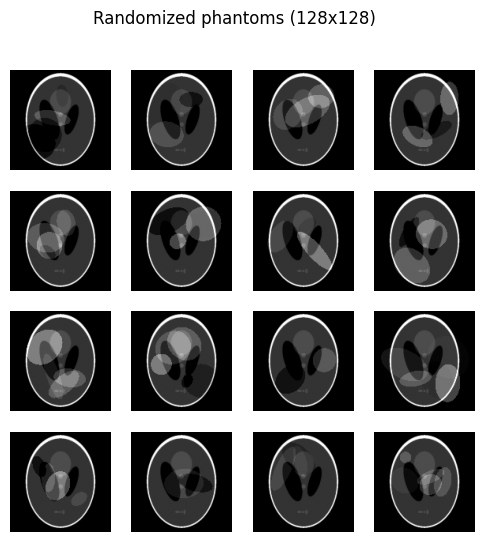

In [ ]:
def draw_ellipse(img, cy, cx, ay, ax, theta, val):
    """ draws ellipses with desired size and position"""
    H, W = img.shape
    y, x = np.ogrid[:H, :W]
    yt = (y - cy); xt = (x - cx)
    c, s = np.cos(theta), np.sin(theta)
    xr =  (xt*c + yt*s)
    yr = (-xt*s + yt*c)
    mask = (xr*xr)/(ax*ax + 1e-8) + (yr*yr)/(ay*ay + 1e-8) <= 1.0
    img[mask] += val

def make_random_phantom(size=128, n_extra=3):
    """makes random phantoms"""
    #TODO: First, generate a 2D Shepp-Logan phantom as a NumPy array of floats.
    # Then, resize it to the desired size × size using interpolation while keeping the values between 0 and 1.
    base = skt.resize(shepp_logan_phantom(), (size, size), anti_aliasing=True).astype(np.float32)
    phantom = base.copy()

    for _ in range(n_extra):
        cy = np.random.uniform(0.25*size, 0.75*size)
        cx = np.random.uniform(0.25*size, 0.75*size)
        ay = np.random.uniform(0.05*size, 0.2*size)
        ax = np.random.uniform(0.05*size, 0.25*size)
        theta = np.random.uniform(0, np.pi)
        val = np.random.uniform(-0.15, 0.3)
        draw_ellipse(phantom, cy, cx, ay, ax, theta, val)
    phantom = np.clip(phantom, 0.0, 1.0)
    return phantom

# Visualize
imgs = [make_random_phantom(CFG.img_size, n_extra=np.random.randint(2,6)) for _ in range(16)]
fig, axes = plt.subplots(4,4, figsize=(6,6))
for ax, im in zip(axes.ravel(), imgs):
    ax.imshow(im, cmap='gray'); ax.axis('off')
plt.suptitle("Randomized phantoms (128x128)"); plt.show()

## Radon Transform — Theory & CT Motivation

The **Radon Transform** converts a 2D object $ f(x,y) $ into a set of **1D line integrals** taken at different angles.  
Each integral represents X-ray attenuation measured by a detector as rays pass through the object:

$$
R f(\theta, s) = \int_{-\infty}^{+\infty} f(x,y)\, \mathrm{d}l
$$

where:
- $ \theta $ = projection angle
- $ s $ = detector position perpendicular to each projection line

The collection of all projections vs. angle forms a **sinogram**, the raw data acquired in CT scanners.

---

X-ray CT systems measure how much radiation is absorbed along each ray path.  
These are **exactly** Radon line integrals.  
Thus, reconstructing the image means **inverting** the Radon transform.

$$
f(x,y) = R^{-1}\{ \text{sinogram} \}
$$


Understanding forwards (projection) and backwards (reconstruction) operations is essential for improving CT quality, reducing radiation dose, and developing modern iterative / deep-learning-based reconstruction methods.




### Fourier Slice Theorem

**Question:** Read about Fourier Slice Theorem. How does the Radon transform relate each projection to the 2D Fourier Transform of the image?

**Answer:**
**Fourier Slice Theorem:**

The 1D Fourier transform of a projection at angle $\theta $ is equal to a slice of the 2D Fourier transform of the image taken along the same angle:

$$
\mathcal{F}_{1D}\{ p_\theta(t) \}(\omega)
=
\mathcal{F}_{2D}\{ f(x,y) \}(\omega \cos\theta,\; \omega \sin\theta)
$$

Where:

- $ p_\theta(t)$ is the Radon projection of $f(x,y)$ at angle $\theta$
- $ \mathcal{F}_{1D} $ is the 1D Fourier transform of the projection
- $ \mathcal{F}_{2D} $ is the 2D Fourier transform of the original image
- $ \omega \cos\theta, \omega \sin\theta $ give coordinates on a radial line in frequency space.

**Interpretation:**
A projection at angle $\theta$ corresponds to a **line (slice)** through the 2D Fourier transform of the image at the same angle.




## 2) From-scratch Radon (Forward Projection) (10 pts)
This cell implements a naive Radon transform: the image is rotated by each projection angle θ and the values along its columns are summed to form one projection line in the sinogram. By repeating this over many angles, we build a full sinogram that represents how the object would be measured by a CT scanner.

→ You will then compare your simple implementation to skimage.radon to observe differences due to interpolation, padding, and assumptions about the circular support.


Simple shape: (128, 180)
Skimage shape: (128, 180)


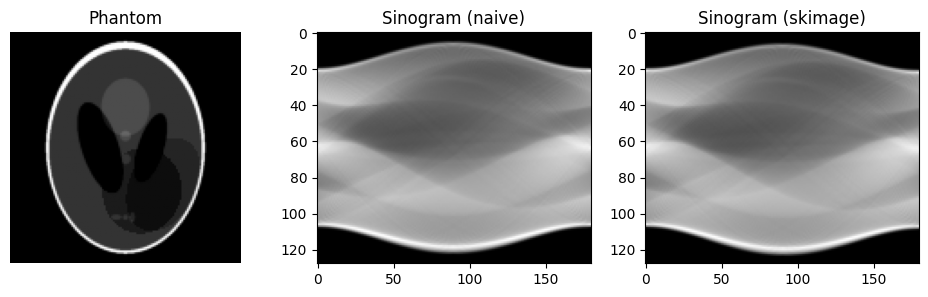

Mean abs diff naive vs skimage: 0.6017177700996399


In [ ]:
def radon_simple(img: np.ndarray, angles_rad: np.ndarray) -> np.ndarray:
    """"Computes a sinogram by rotating the image to each given angle and
    summing the pixel values along one axis.
    Collect all projections into a 2D array."""
    angles_deg = np.rad2deg(angles_rad)
    proj = []
    for ang in angles_deg:
        rotated = skt.rotate(img, ang, resize=False, mode='edge')
        proj.append(rotated.sum(axis=0))
    sino = np.stack(proj, axis=1)
    return sino[::-1, ::-1]

phantom = make_random_phantom(CFG.img_size, n_extra=np.random.randint(2,6))
angles_full = np.linspace(0, np.pi, CFG.angles_180, endpoint=False)
angles_deg = np.rad2deg(angles_full)
sino_naive = radon_simple(phantom, angles_full)
sino_ski = sk_radon(phantom, angles_deg)

print(f"Simple shape: {sino_naive.shape}")
print(f"Skimage shape: {sino_ski.shape}")

fig, axs = plt.subplots(1,3, figsize=(12,3))
axs[0].imshow(phantom, cmap='gray'); axs[0].set_title("Phantom"); axs[0].axis('off')
axs[1].imshow(sino_naive, cmap='gray', aspect='auto'); axs[1].set_title("Sinogram (naive)")
axs[2].imshow(sino_ski,   cmap='gray', aspect='auto'); axs[2].set_title("Sinogram (skimage)")
plt.show()

print("Mean abs diff naive vs skimage:", float(np.abs(sino_naive - sino_ski).mean()))


## 3) Low-dose Poisson Noise & Limited-angle (10 pts)

We convert line integrals $p$ to counts: $I=I_0 e^{-p}$, sample Poisson, then invert: $\tilde{p}=-\log(\tilde{I}/I_0)$.


This cell simulates realistic CT data by adding **Poisson (photon) noise** to the sinogram. In X-ray CT, detectors measure photon counts $I$, not line-integral values directly. So we convert each projection value $p$ into expected counts using the exponential attenuation model (Beer–Lambert law):

$$ I = I_0 e^{-p} $$

Then, to imitate low-dose CT, we draw noisy photon counts from a Poisson distribution (since X-ray photons arrive as discrete random events), and convert the noisy counts back into projection space:

$$ \tilde{p} = -\log\left(\frac{\tilde{I}}{I_0}\right) $$

A correct implementation must handle:
- Normalizing the sinogram before applying noise
- Avoiding $\log(0)$ by clamping counts to a minimum value
- Preserving the overall structure of the projections

Clean sinogram
  Min: 0.000, Max: 30.575
  Mean: 14.217, Std: 7.973
Shape of sino clean: (128, 180)
Shape of sino_noisy: ((128, 180))
Shape of sino_limited: ((128, 120))


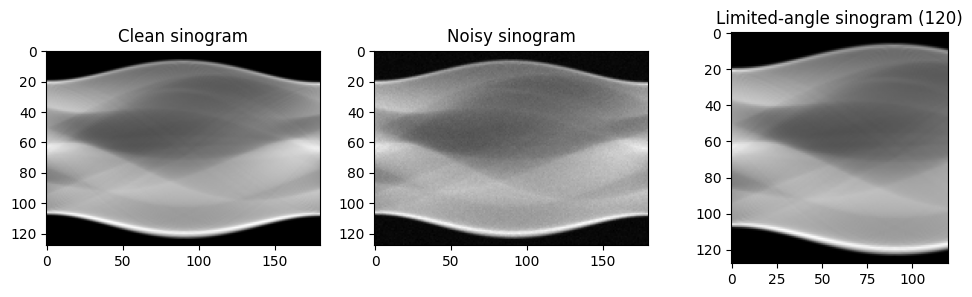

In [ ]:
def add_poisson_noise_to_sinogram(sino: np.ndarray, I0=1e4, eps=1e-8) -> np.ndarray:
    """applies Poisson noise to the imagegiven the description above"""
    sino_norm = (sino - sino.min()) / (sino.max() - sino.min())
    I_clean = I0 * np.exp(-sino_norm)
    I_noisy = np.maximum(np.random.poisson(I_clean), 1)
    sino_noisy = -np.log(I_noisy / I0 + eps)
    return sino_noisy

angles_lim = np.linspace(0, np.deg2rad(CFG.limited_deg), CFG.limited_deg, endpoint=False)
sino_clean = sk_radon(phantom, np.rad2deg(angles_full), circle=True)

print("Clean sinogram")
print(f"  Min: {sino_clean.min():.3f}, Max: {sino_clean.max():.3f}")
print(f"  Mean: {sino_clean.mean():.3f}, Std: {sino_clean.std():.3f}")

I0 = CFG.I0
sino_noisy = add_poisson_noise_to_sinogram(sino_clean, I0, CFG.eps)
sino_limited = sk_radon(phantom, np.rad2deg(angles_lim), circle=True)

print(f"Shape of sino clean: {sino_clean.shape}")
print(f"Shape of sino_noisy: ({sino_noisy.shape})")
print(f"Shape of sino_limited: ({sino_limited.shape})")

fig, axs = plt.subplots(1,3, figsize=(12, 3))
axs[0].imshow(sino_clean, cmap='gray')
axs[0].set_title("Clean sinogram")
axs[1].imshow(sino_noisy, cmap='gray')
axs[1].set_title("Noisy sinogram")
axs[2].imshow(sino_limited, cmap='gray')
axs[2].set_title(f"Limited-angle sinogram ({CFG.limited_deg})")
plt.show()

**Question:** Why does increasing $I_0$ (the number of input photons) reduce noise in CT measurements, while increasing the maximum $p$ value (stronger attenuation) increases noise?

**Answer:**
*In CT imaging, increasing the incident photon count $I_0$ reduces noise because X-ray measurements follow **Poisson statistics**, where the noise standard deviation is $ \sqrt{I}$ and the signal-to-noise ratio scales as $ \sqrt{I} $. When more photons reach the detector, the relative fluctuation $ \frac{\sqrt{I}}{I} $ becomes smaller, resulting in less noisy projection data. Therefore, increasing X-ray tube current or exposure (higher $ I_0 $) improves SNR and produces cleaner CT reconstructions.*

*In contrast, increasing the attenuation $ p $ in tissue makes the measurements noisier. From the Beer–Lambert law $ p = -\ln\left(\frac{I}{I_0}\right) $, higher attenuation reduces the detected photon count $ I $. Low photon counts lead to higher relative Poisson noise $\frac{1}{\sqrt{I}}$, and the logarithmic transform amplifies this noise even further. Thus, highly attenuating regions—bone, thick tissues, metal—produce noisier sinograms and degrade reconstruction quality.*



## 4) FBP: Filters & Backprojection (25 pts)

Filtered Backprojection is the classical and most widely used method for CT image reconstruction. It has two main steps:

---

### 1 Frequency-Domain Filtering

Each projection (row of the sinogram) is first transformed into the frequency domain using the 1D Fourier Transform.  

The ideal inverse Radon solution requires multiplying by a **ramp filter**:

$$ H_{\text{ramp}}(f) = |f| $$

This corrects the low-frequency bias introduced by plain backprojection and emphasizes high frequencies (edges).  
However, ramp filtering can amplify noise — so we often apply **windowed variants**:

- **Shepp–Logan**: ramp × sinc → soft high-frequency reduction  
- **Hann**: ramp × Hann window → stronger noise suppression  

After filtering in frequency space, we invert back to the spatial domain to get filtered projections.

---

### 2 Backprojection

Each filtered projection is then **smeared back** into the image at its corresponding angle:

- For angle $\theta$, copy the projection across the image as parallel lines
- Rotate this “smear” back by $\theta$
- Sum contributions from all angles

Finally, we normalize by a constant factor to correctly scale the reconstructed values.


FBP implements the **Fourier Slice Theorem** in practice:  
filtering recovers the correct frequency balance, and backprojection collects the slices to form the full 2D image.



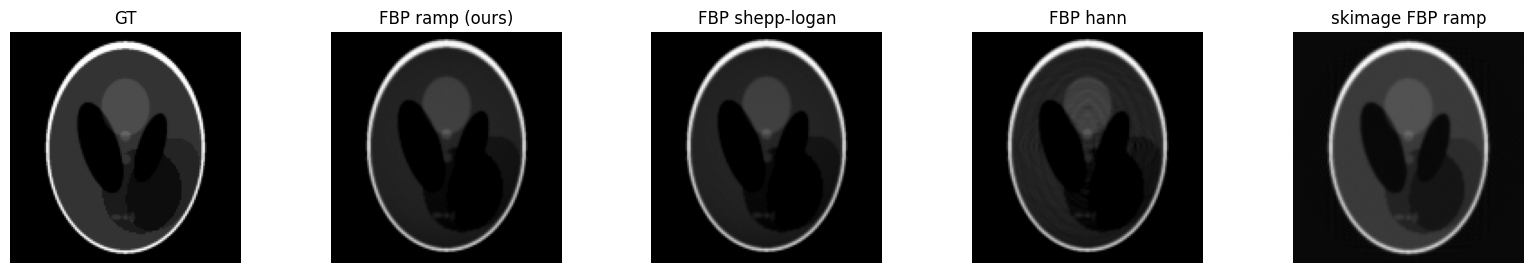

ours ramp PSNR: 15.058477239471987 SSIM: 0.5424667328662254
ours shepp-logan PSNR: 15.051390796135095 SSIM: 0.5421429942187904
ours hann PSNR: 15.028568188636914 SSIM: 0.5405704976590483
skimage ramp PSNR: 28.626744654920344 SSIM: 0.9611669939819266


In [ ]:
def fbp_filter(n_det: int, filter_name: str = 'ramp'):
    """Implement a frequency-domain filter for filtered backprojection.
    Compute the ramp filter and optionally modify it for Shepp-Logan or Hann windowing."""
    freqs = np.fft.rfftfreq(n_det, d=1.0)
    ramp = np.abs(freqs)
    if filter_name == 'ramp':
        H = ramp
    elif filter_name == 'shepp-logan':
        H = ramp * np.sinc(freqs / 2)
    elif filter_name == 'hann':
        hann = 0.5 * (1 + np.cos(np.pi * freqs / 1e-16))
        H = ramp * hann
    else:
        raise ValueError("Unknown filter")
    return H

def fbp_reconstruct(sino: np.ndarray, angles: np.ndarray, filter_name='ramp', output_size=128) -> np.ndarray:
    """TODO: Implement filtered backprojection: apply a frequency-domain filter to each projection in the sinogram,
      inverse-transform it, and then backproject all filtered projections over the image grid to reconstruct the original image."""
    n_det, n_angles = sino.shape
    H = fbp_filter(n_det, filter_name=filter_name)
    sino_f = np.fft.rfft(sino.T, axis=1)
    filtered_sino_f = sino_f * H[None, :]
    filtered_sino = np.fft.irfft(filtered_sino_f, n=n_det, axis=1)

    recon = np.zeros((output_size, output_size), dtype=np.float32)
    cent =  output_size // 2
    x, y = np.mgrid[-cent:cent, -cent:cent]
    for i, th in enumerate(angles):
        # ray coordinate: t = x cosθ + y sinθ
        t = x * np.cos(th) + y * np.sin(th)
        # convert to detector index
        t_idx = t + cent
        # interpolate
        vals = np.interp(t_idx.ravel(), np.arange(n_det), filtered_sino[i, :])
        recon += vals.reshape(output_size, output_size)

    # constant scale factor
    recon = (recon - filtered_sino[0, :].sum()) / (n_angles - 1)
    recon = np.clip(recon, 0.0, 1.0)
    recon = np.flip(recon.T, axis=0)
    return recon

angles_full = np.linspace(0.0, np.pi, CFG.angles_180, endpoint=False)
sino_clean = sk_radon(phantom, np.rad2deg(angles_full), circle=True)

fbp_ramp = fbp_reconstruct(sino_clean, angles_full, filter_name='ramp', output_size=CFG.img_size)
fbp_sl   = fbp_reconstruct(sino_clean, angles_full, filter_name='shepp-logan', output_size=CFG.img_size)
fbp_hann = fbp_reconstruct(sino_clean, angles_full, filter_name='hann', output_size=CFG.img_size)
fbp_sk = sk_iradon(sino_clean, np.rad2deg(angles_full), filter_name='shepp-logan', circle=True)

def show_row(row, titles):
    fig,axs=plt.subplots(1,len(row), figsize=(4*len(row),3))
    for ax,im,t in zip(axs,row,titles):
        ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
    plt.show()

show_row([phantom, fbp_ramp, fbp_sl, fbp_hann, fbp_sk],
         ["GT","FBP ramp (ours)","FBP shepp-logan","FBP hann","skimage FBP ramp"])

for name, rec in [("ours ramp", fbp_ramp),("ours shepp-logan", fbp_sl),("ours hann", fbp_hann),("skimage ramp", fbp_sk)]:
    print(name, "PSNR:", psnr(phantom, rec, data_range=1.0), "SSIM:", ssim(phantom, rec, data_range=1.0))

**Question:** Why does the ramp filter sharpen edges but also make the reconstruction more sensitive to noise?

**Answer:**
*The ramp filter ($H(f) = |f|$) amplifies high spatial frequencies in the projection data, which correspond to sharp edges and fine structural details in the image. By boosting these high-frequency components, the filter counteracts the blurring effect of simple backprojection and produces sharper, more accurate edges in the reconstruction.*

*However, noise in CT measurements is also concentrated in the high-frequency range. Because the ramp filter increases the gain for high frequencies, it amplifies noise along with true edge information. This makes the reconstruction more sensitive to measurement noise, leading to grainier or streakier images when the input data are noisy.*

Apply fbp filter with a limited degree to see the results.

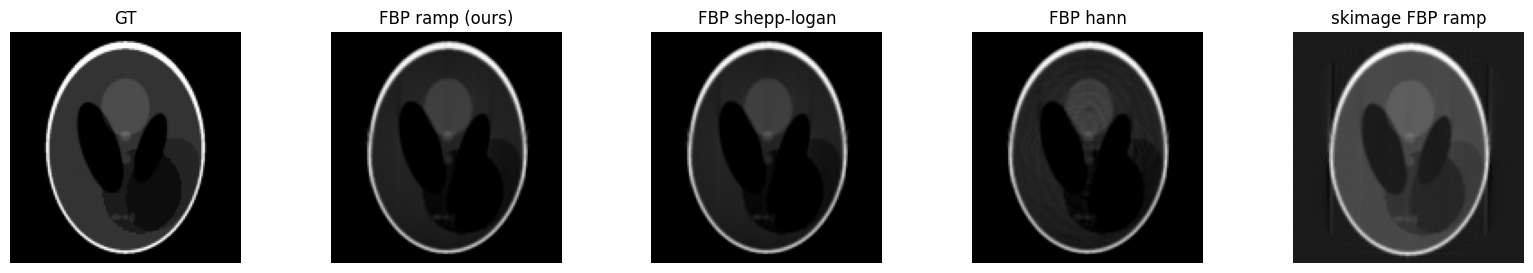

ours ramp PSNR: 15.143966932431177 SSIM: 0.5462401392371108
ours shepp-logan PSNR: 15.135345316391692 SSIM: 0.5458084053250394
ours hann PSNR: 15.1082515979991 SSIM: 0.5439549347050253
skimage ramp PSNR: 16.914941234972936 SSIM: 0.40486003241555235


In [ ]:
CFG.limited_deg = 150
angles_full = np.linspace(0, np.pi, CFG.angles_180, endpoint=False)
angles_lim = np.linspace(0, np.deg2rad(CFG.limited_deg), CFG.angles_180, endpoint=False)
sino_clean = radon_simple(phantom, angles_full)

fbp_ramp = fbp_reconstruct(sino_clean, angles_full, filter_name='ramp')
fbp_sl   = fbp_reconstruct(sino_clean, angles_full, filter_name='shepp-logan')
fbp_hann = fbp_reconstruct(sino_clean, angles_full, filter_name='hann')
fbp_sk = sk_iradon(sino_clean, np.rad2deg(angles_full), filter_name='ramp', output_size=CFG.img_size)
fbp_sk = (fbp_sk - fbp_sk.min()) / (fbp_sk.max() - fbp_sk.min() + 1e-8)

def show_row(row, titles):
    fig,axs=plt.subplots(1,len(row), figsize=(4*len(row),3))
    for ax,im,t in zip(axs,row,titles):
        ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
    plt.show()

show_row([phantom, fbp_ramp, fbp_sl, fbp_hann, fbp_sk],
         ["GT","FBP ramp (ours)","FBP shepp-logan","FBP hann","skimage FBP ramp"])

for name, rec in [("ours ramp", fbp_ramp),("ours shepp-logan", fbp_sl),("ours hann", fbp_hann),("skimage ramp", fbp_sk)]:
    print(name, "PSNR:", psnr(phantom, rec, data_range=1.0), "SSIM:", ssim(phantom, rec, data_range=1.0))

# part 2: denoising

## 5) Making a Dataset for Denoising: (FBP_noisy → GT) (5 pts)

We generate (input, target) pairs with **60 views**.  
**Input:** FBP of Poisson-noisy sinogram. **Target:** ground-truth phantom.


In [ ]:
def make_dataset(n_samples, img_size, angles, I0, filt='ramp'):
    X=[]; Y=[]
    ang_deg = np.rad2deg(angles)
    for _ in tqdm(range(n_samples)):
        gt_phantom = make_random_phantom(img_size, n_extra=np.random.randint(2,6))
        sino_clean = sk_radon(gt_phantom, ang_deg, circle=True)
        sino_noisy = add_poisson_noise_to_sinogram(sino_clean, I0, CFG.eps)
        recon_noisy = fbp_reconstruct(sino_noisy, angles, filter_name=filt)
        X.append(recon_noisy)
        Y.append(gt_phantom)

    X = np.stack(X)[:, None, :, :].astype(np.float32)
    Y = np.stack(Y)[:, None, :, :].astype(np.float32)
    return X,Y

n_train, n_val, n_test = 800, 100, 100

# angles_60 = np.linspace(0, np.pi, 120, endpoint=False)
limited_angle = 180
angles_lim = np.linspace(0, math.radians(limited_angle), CFG.angles_180 * limited_angle // 180, endpoint=False)
Xtr,Ytr = make_dataset(n_train, CFG.img_size, angles_lim, CFG.I0, 'ramp')
Xva,Yva = make_dataset(n_val,   CFG.img_size, angles_lim, CFG.I0, 'ramp')
Xte,Yte = make_dataset(n_test,  CFG.img_size, angles_lim, CFG.I0, 'ramp')
Xtr.shape, Ytr.shape


100%|██████████| 100/100 [00:13<00:00,  7.68it/s]


((800, 1, 128, 128), (800, 1, 128, 128))

### 5.1 Visualize a random training triplet

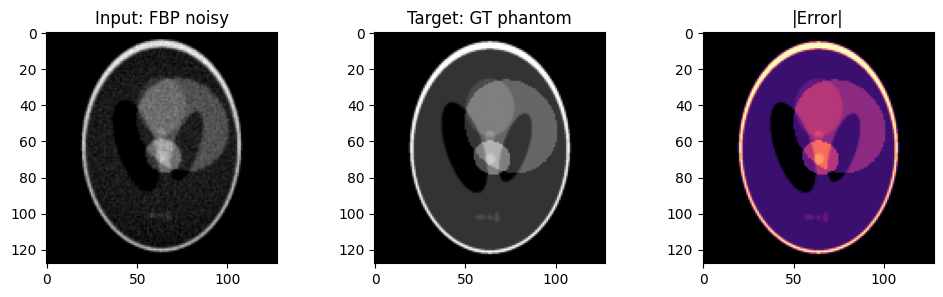

In [ ]:
def show_triplet(X,Y,idx=None):
    """Visualize a single sample from the dataset by displaying three images side by side:
    the input (FBP reconstruction with noise), the target ground truth phantom, and the absolute error between them. idx is the sample index in the dataset"""

    if idx is None: idx = np.random.randint(0, len(X))

    x = X[idx, 0]; y = Y[idx, 0]
    err = np.abs(x - y)

    _, axs = plt.subplots(1,3, figsize=(12, 3))
    axs[0].imshow(x, cmap='gray')
    axs[0].set_title("Input: FBP noisy")
    axs[1].imshow(y, cmap='gray')
    axs[1].set_title("Target: GT phantom")
    axs[2].imshow(err, cmap='magma')
    axs[2].set_title("|Error|")
show_triplet(Xtr,Ytr)


## 6) Torch DataLoaders (5 pts)


In [ ]:
class PairDataset(Dataset):
    """Create a PyTorch dataset class that wraps paired NumPy arrays X (inputs) and Y (targets).
    Implement __len__ and __getitem__"""
    def __init__(self,X,Y):
      self.X= torch.from_numpy(np.array(X))
      self.Y= torch.from_numpy(np.array(Y))
    def __len__(self):
      return len(self.X)
    def __getitem__(self,i):
      return self.X[i], self.Y[i]

train_ds, val_ds, test_ds = PairDataset(Xtr,Ytr), PairDataset(Xva,Yva), PairDataset(Xte,Yte)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)

(800, 100, 100)


## 7) Tiny U-Net-lite Denoiser (Supervised L1/L2) (20 pts)

**Input:** 1×128×128 noisy-FBP  
**Output:** 1×128×128 denoised  
We'll train with **L1** and **L2**.


In [ ]:
class DoubleConv(nn.Module):
    """Implement a building block with two consecutive convolutional layers,
    each followed by batch normalization and ReLU activation.
    This block preserves spatial size while increasing feature channels"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                                 nn.BatchNorm2d(out_ch),
                                 nn.ReLU(),
                                 nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                                 nn.BatchNorm2d(out_ch),
                                 nn.ReLU(),
                                 )
    def forward(self,x):
        return self.net(x)

class UNetLite(nn.Module):
    def __init__(self, base=24):
        """Implement a lightweight U-Net for image-to-image reconstruction:
        first, create downsampling blocks using DoubleConv and max-pooling to extract hierarchical features;
        then apply a bottleneck DoubleConv at the lowest resolution.
        Upsample step by step using transposed convolutions, concatenate features from the corresponding downsampling layers (skip connections),
        and apply DoubleConv after each concatenation. Finally, use a 1×1 convolution to produce the output image.
        The forward method should connect all these steps and return the reconstructed image."""
        super().__init__()
        # Downsample
        self.down1 = DoubleConv(1, base)
        self.down2 = DoubleConv(base, 2*base)
        self.down3 = DoubleConv(2*base, 4*base)

        #Bottleneck
        self.bottleneck = DoubleConv(4*base, 8*base)

        #Upsample
        self.trans1 = nn.ConvTranspose2d(8*base, 4*base, kernel_size=2, stride=2)
        self.up1 = DoubleConv(8*base, 4*base)
        self.trans2 = nn.ConvTranspose2d(4*base, 2*base, kernel_size=2, stride=2)
        self.up2 = DoubleConv(4*base, 2*base)
        self.trans3 = nn.ConvTranspose2d(2*base, base, kernel_size=2, stride=2)
        self.up3 = DoubleConv(2*base, base)
        self.out = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self,x):
        #Encode path
        x1 = self.down1(x) # 1 x 128 128 --> 24 x 128 x 128
        pooled1 = F.max_pool2d(x1, kernel_size=2, stride=2) # 24 x 128 128 --> 24 x 64 x 64
        x2 = self.down2(pooled1) # 24 x 64 x 64 --> 48 x 64 x 64
        pooled2 = F.max_pool2d(x2, kernel_size=2, stride=2) # 48 x 64 x 64 --> 48 x 32 x 32
        x3 = self.down3(pooled2)  # 48 x 32 x 32 --> 96 x 32 x 32
        pooled3 = F.max_pool2d(x3, kernel_size=2, stride=2) # 96 x 32 x 32 --> 96 x 16 x 16

        #Bottleneck
        z = self.bottleneck(pooled3) # 96 x 16 x 16 --> 192 x 16 x 16

        #Decode path
        y1 = self.trans1(z) # 192 x 16 x 16 --> 96 x 32 x 32
        y1 = torch.cat([y1, x3], dim=1) # 96 x 32 x 32 + 96 x 32 x 32 --> 192 x 32 x 32
        y1 = self.up1(y1) # 192 x 32 x 32 --> 96 x 32 x 32

        y2 = self.trans2(y1) # 96 x 32 x 32 --> 48 x 64 x 64
        y2 = torch.cat([y2, x2], dim=1)  # 48 x 64 x 64 + 48 x 64 x 64 --> 96 x 64 x 64
        y2 = self.up2(y2) # 96 x 64 x 64 --> 48 x 64 x 64

        y3 = self.trans3(y2) # 48 x 64 x 64 --> 24 x 128 x 128
        y3 = torch.cat([y3, x1], dim=1) # 24 x 128 x 128 + 24 x 128 x 128 --> 48 x 128 x 128
        y3 = self.up3(y3) # 48 x 128 x 128 --> 24 x 128 x 128

        out = self.out(y3) # 24 x 128 x 128 --> 1 x 128 x 128
        return out

model=UNetLite(base=24).to(device)
sum(p.numel() for p in model.parameters())/1e6

1.085305


## 8) Train the Denoiser (10 pts)


In [ ]:
def train_epoch(model, loader, opt, scaler=None, loss_type='l1'):

    """Set the model to training mode.
    Loop over the data loader, moving inputs and targets to the device. Zero the optimizer gradients.
    Forward the input through the model and compute the loss (L1, MSE, or a combination).
    Backpropagate the loss, and update the optimizer.
    Accumulate the total loss and return the average over all samples."""
    all_loss = 0
    count = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        if scaler is not None:
            with torch.autocast(device.type):
                  pred = model(x)
                  if loss_type == 'l1':
                      loss = F.l1_loss(pred, y)
                  elif loss_type == 'l2':
                      loss = F.mse_loss(pred, y)
                  elif loss_type == 'combined':
                      loss = F.l1_loss(pred, y) + F.mse_loss(pred, y)
                  else:
                      raise ValueError("Unknown loss type")
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

        else:
            pred = model(x)
            if loss_type == 'l1':
                loss = F.l1_loss(pred, y)
            elif loss_type == 'l2':
                loss = F.mse_loss(pred, y)
            elif loss_type == 'combined':
                  loss = F.l1_loss(pred, y) + F.mse_loss(pred, y)
            else:
                raise ValueError("Unknown loss type")
            loss.backward()
            opt.step()

        all_loss += loss.item()*x.size(0)
        count += x.size(0)

    return all_loss/count

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval(); total=0; L1=L2=PS=SS=0.0
    for x,y in loader:
        x,y=x.to(device), y.to(device)
        pred=model(x)
        L1 += F.l1_loss(pred,y,reduction='sum').item()
        L2 += F.mse_loss(pred,y,reduction='sum').item()
        pn=pred.detach().cpu().numpy(); yn=y.detach().cpu().numpy()
        for i in range(pn.shape[0]):
            PS += psnr(yn[i,0], pn[i,0], data_range=1.0)
            SS += ssim(yn[i,0], pn[i,0], data_range=1.0)
        total += x.size(0)
    return {'L1': L1/(total*CFG.img_size*CFG.img_size),
            'L2': L2/(total*CFG.img_size*CFG.img_size),
            'PSNR': PS/total, 'SSIM': SS/total}

batch_size = 16
epochs = 15
lr =5e-4
weight_decay = 1e-5
use_amp = True
opt=torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scaler=torch.amp.GradScaler("cuda") if (device.type=='cuda' and use_amp) else None

train_total_losses = []
val_l1_losses = []
val_l2_losses = []
val_total_losses = []

best=-float("inf")
best_state=None

for ep in range(1, epochs+1):
    """#TODO: Train the model for one epoch and record the training loss.
    Evaluate the model on the validation set and record L1, L2, and combined losses.
    Print epoch metrics including PSNR and SSIM.
    Keep track of the best-performing model (highest PSNR + SSIM) and save its state."""
    train_loss = train_epoch(model, train_loader, opt, scaler=scaler, loss_type='combined')
    train_total_losses.append(train_loss)
    val_metrics = eval_epoch(model, val_loader)
    print(f"Epoch {ep} | train total loss: {train_loss:.5f} | val L1 loss: {val_metrics['L1']:.5f} L2 loss: {val_metrics['L2']:.5f} PSNR: {val_metrics['PSNR']:.5f} SSIM: {val_metrics['SSIM']:.5f}")

    if val_metrics['PSNR'] + val_metrics['SSIM'] > best:
        best = val_metrics['PSNR'] + val_metrics['SSIM']
        best_state = model.state_dict()

if best_state is not None:
    model.load_state_dict(best_state)
test_metrics=eval_epoch(model, test_loader)
print("TEST metrics:", test_metrics)

Epoch 1 | train total loss: 0.02284 | val L1 loss: 0.00860 L2 loss: 0.00030 PSNR: 36.19482 SSIM: 0.93574
Epoch 2 | train total loss: 0.00769 | val L1 loss: 0.00677 L2 loss: 0.00024 PSNR: 37.28073 SSIM: 0.96426
Epoch 3 | train total loss: 0.00592 | val L1 loss: 0.00562 L2 loss: 0.00020 PSNR: 37.93501 SSIM: 0.97294
Epoch 4 | train total loss: 0.00583 | val L1 loss: 0.00664 L2 loss: 0.00023 PSNR: 37.20409 SSIM: 0.96634
Epoch 5 | train total loss: 0.00579 | val L1 loss: 0.00566 L2 loss: 0.00021 PSNR: 37.85139 SSIM: 0.97440
Epoch 6 | train total loss: 0.00596 | val L1 loss: 0.00835 L2 loss: 0.00027 PSNR: 36.40004 SSIM: 0.97102
Epoch 7 | train total loss: 0.00665 | val L1 loss: 0.00577 L2 loss: 0.00021 PSNR: 37.78719 SSIM: 0.97351
Epoch 8 | train total loss: 0.00564 | val L1 loss: 0.00632 L2 loss: 0.00020 PSNR: 37.72739 SSIM: 0.96728
Epoch 9 | train total loss: 0.00570 | val L1 loss: 0.00521 L2 loss: 0.00019 PSNR: 38.32534 SSIM: 0.97554
Epoch 10 | train total loss: 0.00548 | val L1 loss: 0.0

**Note:** you should try to reach $SSIM>98%$ and $PSNR>39$ in test sets for a full grade.


## 9) Qualitative: Side-by-side & Error Maps (5 pts)

To visually evaluate the model’s performance, we compare:

1. Input FBP (noisy)  
2. Model output (denoised)  
3. Ground truth phantom  

Then we compute two error maps:

4. $|x - y|$: error of the noisy input
5. $|p - y|$: error of the model prediction

6.To highlight improvement, we also show a **difference map**:

$$
\Delta = \big|x - y\big| - \big|p - y\big|
$$

Use:
- `cmap='gray'` for reconstructed images  
- `cmap='magma'` for error maps
- `cmap='bwr'` for the difference map  


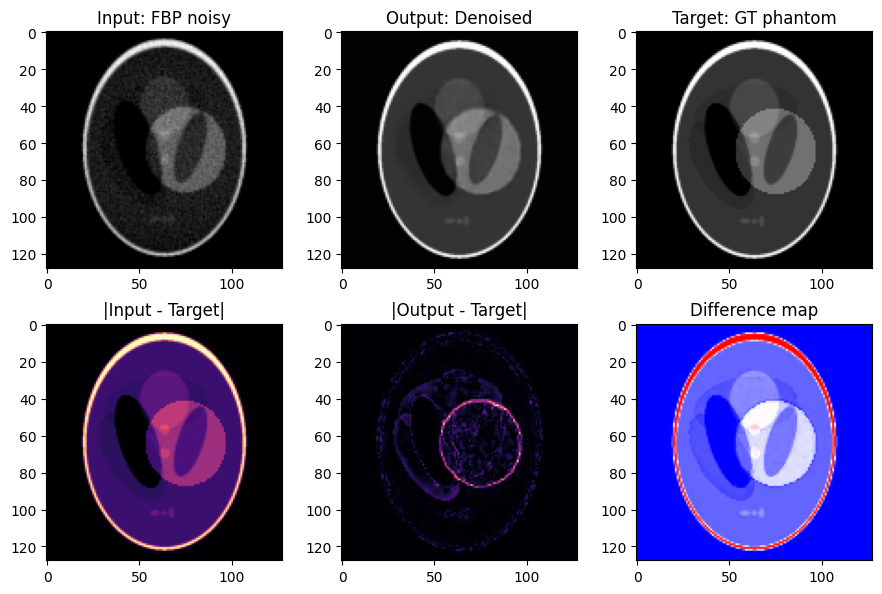

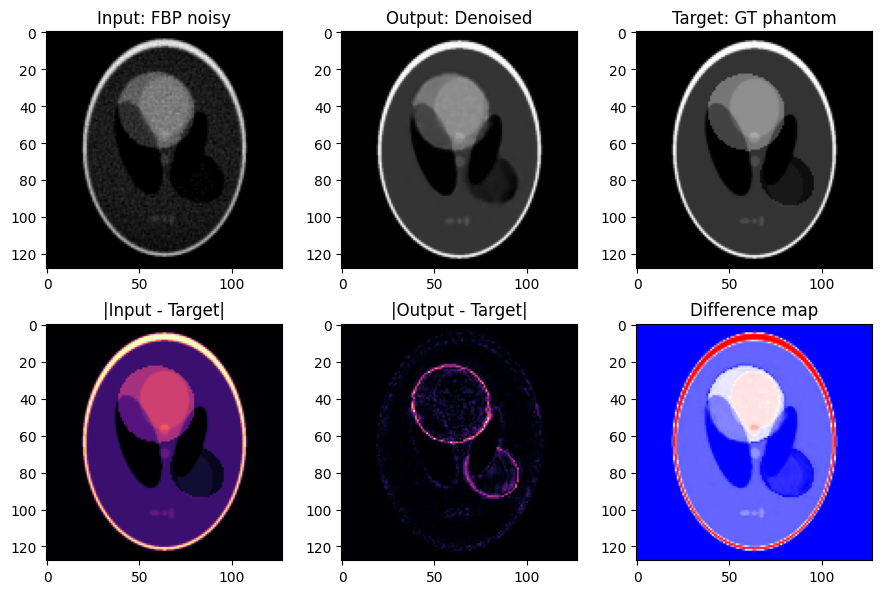

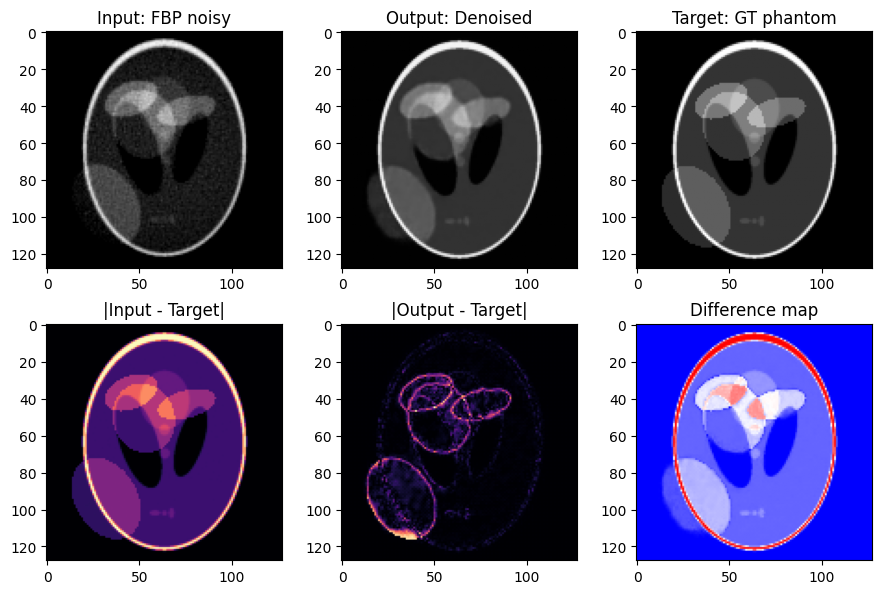

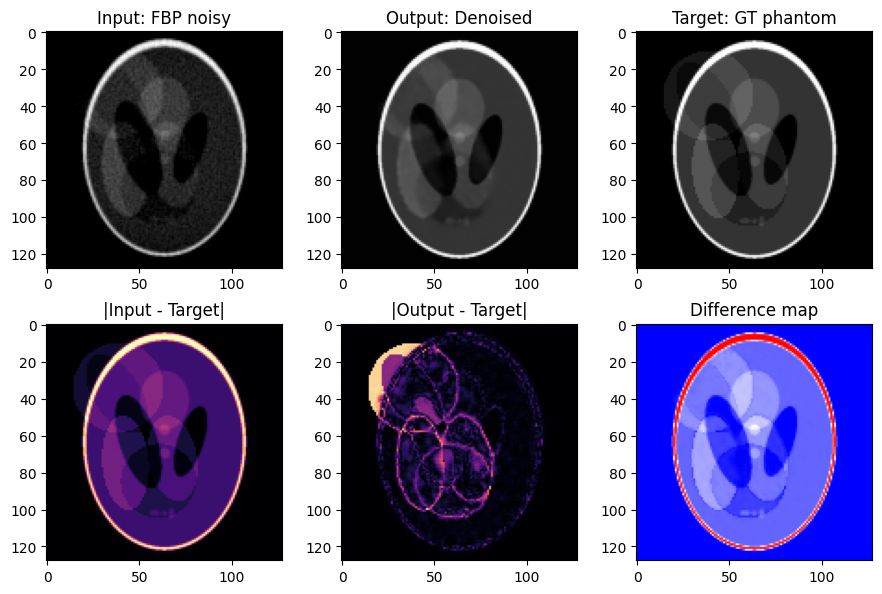

In [ ]:
@torch.no_grad()
def show_qualitative(model, loader, n=4):
    model.eval(); shown=0
    for x,y in loader:
        x,y=x.to(device), y.to(device)
        pred=model(x)
        for i in range(x.size(0)):
            if shown>=n: return
            xi=x[i,0].cpu().numpy(); yi=y[i,0].cpu().numpy(); pi=pred[i,0].cpu().numpy()
            err_noisy = np.abs(xi- yi)
            err_pred = np.abs(pi - yi)
            diff = np.abs(err_noisy - err_pred)

            fig,axs=plt.subplots(2,3, figsize=(9,6))
            axs[0,0].imshow(xi, cmap='gray')
            axs[0,0].set_title("Input: FBP noisy")
            axs[0,1].imshow(pi, cmap='gray')
            axs[0,1].set_title("Output: Denoised")
            axs[0,2].imshow(yi, cmap='gray')
            axs[0,2].set_title("Target: GT phantom")

            axs[1, 0].imshow(err_noisy, cmap="magma")
            axs[1, 0].set_title("|Input - Target|")
            axs[1, 1].imshow(err_pred, cmap="magma")
            axs[1, 1].set_title("|Output - Target|")
            axs[1, 2].imshow(diff, cmap="bwr")
            axs[1, 2].set_title("Difference map")
            plt.tight_layout()
            plt.show()
            shown+=1

show_qualitative(model, test_loader, n=4)

**Question:** In the red-blue difference map, which color indicates improvement and why? What does it mean when a region shows blue?

**Answer:**
**Question:**  
In the red-blue difference map, which color represents improvement, and why? What does a blue region signify?

**Answer:**  
*The difference map is defined as $|x - y| - |p - y|.$ A positive value of difference map means the original error $|x - y|$ is greater than the new error $|p - y|$. This indicates that the prediction has moved closer to the ground truth, reducing the reconstruction error. A negative difference map implies the updated error is larger than the original one, meaning $|p - y|$ exceeded $|x - y|$. In this case, the model has worsened the result by increasing its deviation from the ground truth.*
